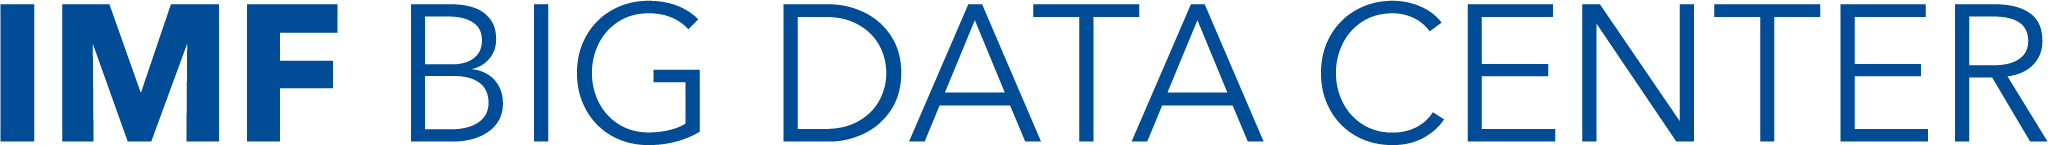

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/BDC_STI_26/blob/main/notebooks/BDC_Trade_Nowcasting_AIS_Portwatch.ipynb)

# Global Trade Nowcasting using PortWatch Data

---

<br>**Contributors:** [Alessandra Sozzi](asozzi@imf.org) & [Mario Saraiva](msaraiva@imf.org)
<br> **Last update:** Oct-2025
<br> **Description:** This notebook implements the IMF PortWatch Nowcasting of Global Trade methodology.
<br> **References:**

You may access the full methodology through the [IMF Working Paper](https://www.imf.org/en/Publications/WP/Issues/2025/05/16/Nowcasting-Global-Trade-from-Space-566957) -  *Arslanalp S., S. M. Choi, P. Kamali, R. Koepke, M. McKetty, M. Ruta, M. Saraiva, A. Sozzi, and J. Verschuur (2025), "Nowcasting Global Trade from Space," IMF Working Paper 2025/093.*

In [44]:
fn = "/content/drive/MyDrive/Colab Notebooks/Portcalls/db/ports/Daily_Trade_Data_REG.csv"
df = pd.read_csv(fn)


In [50]:
sorted_df = df[['ISO3', 'country', 'date', 'portcalls_container', 'portcalls_dry_bulk',
       'portcalls_general_cargo', 'portcalls_roro', 'portcalls_tanker',
       'portcalls_cargo', 'portcalls', 'import_container', 'import_dry_bulk',
       'import_general_cargo', 'import_roro', 'import_tanker', 'import_cargo',
       'import', 'export_container', 'export_dry_bulk', 'export_general_cargo',
       'export_roro', 'export_tanker', 'export_cargo', 'export', 'shipment',
       'portcalls_container_30MA_yoy_doy',
       'shipment_30MA_yoy_doy',
       'import_container_30MA_yoy_doy',
       'export_container_30MA_yoy_doy']].sort_values(['date', 'ISO3'], ascending=False, ignore_index=True)


In [51]:
sorted_df

,ISO3,country,date,portcalls_container,portcalls_dry_bulk,portcalls_general_cargo,portcalls_roro,portcalls_tanker,portcalls_cargo,portcalls,...,export_general_cargo,export_roro,export_tanker,export_cargo,export,shipment,portcalls_container_30MA_yoy_doy,shipment_30MA_yoy_doy,import_container_30MA_yoy_doy,export_container_30MA_yoy_doy
0,ZAF,South Africa,2026-01-23,6,2,0,1,4,9,13,...,0.000000,0.000000,1.379921e+04,1.004154e+05,1.142146e+05,1.201634e+05,0.031008,0.251159,0.063866,0.636979
1,YEM,Yemen,2026-01-23,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-0.285714,-0.165166,-0.171300,0.769106
2,WSM,Samoa,2026-01-23,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-0.125000,-0.539340,-0.644574,1.801652
3,WLD,World,2026-01-23,1294,729,930,265,1459,3218,4677,...,797167.787762,135514.195905,7.993742e+06,2.360654e+07,3.160029e+07,2.067771e+07,-0.031436,0.020636,0.016453,0.024778
4,VUT,Vanuatu,2026-01-23,1,0,0,0,1,1,2,...,0.000000,0.000000,0.000000e+00,1.231586e+02,1.231586e+02,1.317942e+03,0.285714,-0.154680,-0.188567,1.550498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505675,200,Emerging Market and Developing Economies,2019-01-01,576,409,340,49,508,1374,1882,...,383769.736487,13754.209146,3.569143e+06,1.077048e+07,1.433962e+07,9.853641e+06,NaN,NaN,NaN,NaN
505676,163,Euro Area,2019-01-01,111,37,112,28,229,288,517,...,81167.985262,15609.133832,4.595930e+05,1.122213e+06,1.581806e+06,1.696765e+06,NaN,NaN,NaN,NaN
505677,123,Other Advanced Economies (Advanced Economies e...,2019-01-01,216,71,77,26,172,390,562,...,41101.378609,12180.877540,1.003378e+06,4.573283e+06,5.576661e+06,2.389948e+06,NaN,NaN,NaN,NaN
505678,119,Major Advanced Economies (G7),2019-01-01,119,97,111,43,310,370,680,...,45408.991286,15425.623921,1.590701e+06,1.415496e+06,3.006197e+06,1.603921e+06,NaN,NaN,NaN,NaN


In [52]:
sorted_df.to_csv(
    fn, index=False
)

## Goal
Build monthly global trade estimates (value & volume) aligned with how official statistics are compiled.

---

## What we add
- **Timeliness:** Monthly index at ~T+7 business days.  
- **Transparent, replicable inputs.**  
- **Single global method:** One consistent aggregation across ports & vessel types, independent of national release calendars.  
- **Empirical performance:** High fit with benchmark official series; captures major turning points.

---

## Problem
Physical shipment volumes ≠ economic trade volume (e.g., heavy commodities vs high-value manufactures).

## Why Physical Volume ≠ Trade Volume
### Example

* A country imports:
  * **10 cars** each car is 2 tons and costs **20,000 USD per ton**
  * **20 tons** of rice (at **500 USD per ton**).

* Next year, the country imports **20 cars** and **20 tons of rice** at the same prices.  

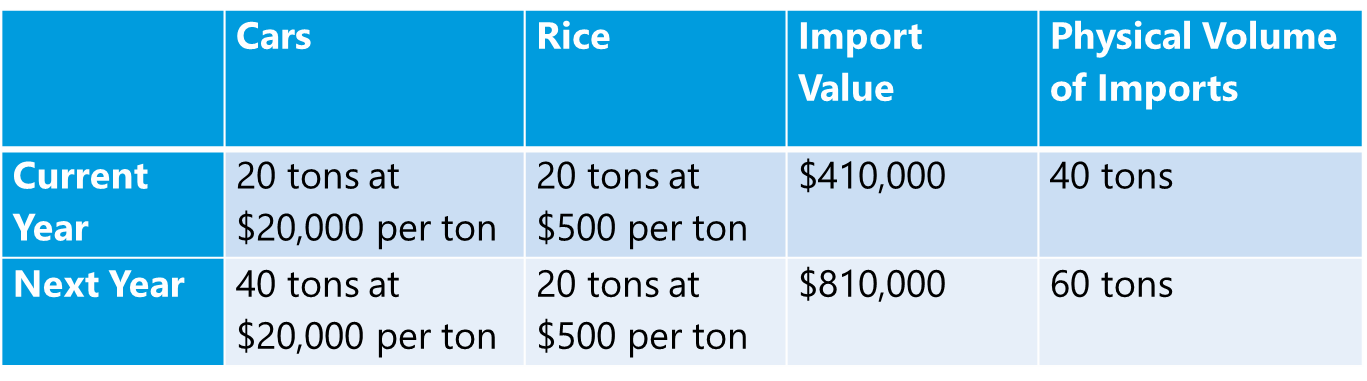
---

**Import Value:** ↑ 100%  
**Physical Volume:** ↑ 50%  
**Official Trade Volume (value deflated by price):** ↑ 100%

> **This tells us that simply aggregating the physical volume of traded goods is not an accurate measure of trade volume as measured by official statistics, particularly when unit values differ**.

## Nowcasting: From Satellite Data to Trade Estimates

### Methodology

1. **Physical Volume**  
   Use AIS data to estimate cargo volume (in metric tons) by vessel type: tankers, dry bulk, and containers.

2. **Trade Value**  
   Multiply physical volume by vessel-type-specific unit values (US$/ton), derived from trade data.

3. **Trade Volume**  
   Deflate trade value using export/import price indices to obtain trade volume in constant prices.

   

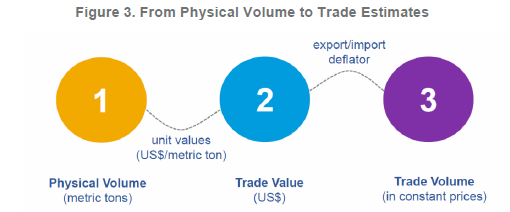


The final output is a **global trade nowcast**.




The main steps in this notebook are the following:

> **Step 1: Build the global vessels shipments in Physical volume (metric tons)**
  - Retrieve PortWatch data for all World Economic Outlook (WEO) regions and the World by 3 major vessel categories: cargo, dry bulk and tanker

> **Step 2: Build the Global Trade Value Index:**
  - Build the prices for each vessel category
    - Build the unit values for the base year: retrieve Baci $/MT unit values
    - Retrive Price Indexes per vessel category
    - Calculate the change in unit values per vessel category
  - Compute Values: prices X portwatch physical volumes

> **Step 3: Build the Global Trade Volume Index**:  
  - Compute Export/Import Deflators
  - Compute Volumes

> *Note: All series are calculated as indices with 2019 as base year*




<h2> Last words before we begin </h2>

<h5> Reminders </h5>

> - ✅ Adjust the path string to your environment
> - ✅ Generate your API Key from the World Trade Organization [WTO API PORTAL](https://apiportal.wto.org/)
> - ✅ The notebook makes request to several APIs, but a dataset has saved as backup. Note the comment #DATA BACKUP throughout the cells.






## Setup

#### Mount the drive and adjust the path

In [ ]:
# Mounth the drive to access file in the Google Drive folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Set the main path for the workshop files

import os

ROOT = "/content/drive/MyDrive/STI 2026"
workshop_path = os.path.join(ROOT, "Day 3 - Trade Nowcasting with PortWatch")
data_path = os.path.join(workshop_path, "input-data")
output_path = os.path.join(workshop_path, "output-data")

# Check if working
print("Worshop path found: ", os.path.exists(workshop_path))
print("Data path found: ", os.path.exists(data_path))
print("Output Data path found: ", os.path.exists(output_path))

Worshop path found:  True
Data path found:  True
Output Data path found:  True


### Libraries

<H4> Installing Additional Library </H4>

In [ ]:
%%capture
!pip install sdmx1

<H4> PortWatch Nowcasting libraries </H4>

In [ ]:
#This allow us to source the functions in the pw_nowcasting_functions.py file
import sys
sys.path.append(workshop_path)

from pw_nowcasting_functions import (
                     ### Functions 1 - Load PortWatch Local Data
                     fetch_portwatch_local, tweak_portwatch_local,

                     ####Functions 2 - Fetch, Tweak and Compile
                     fetch_cpb, tweak_cpb,
                     compile_price_indexes, to_prices, to_laspeyres_price_index,
                     to_value_series,
                     to_volume_weighted_series,
                     fetch_baci_local,

                     #### Functions 3 - Utilities and Calculations
                     bound_dates, to_index,
                     moving_avg, growth_rate, correlate, fetch_and_tweak

                     )

<H4> General libraries </H4>

In [ ]:
import time
import json
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

### Set the latest month for which we have full data

In [ ]:
LAST_MONTH = '2025-12-31'

### Set the Country for this Excercise

In [ ]:
country_id = 'WLD'

## Portwatch data

#### Load data

**Brief function description**

> 🔍`fetch_portwatch_local(filepath)`
  - Loads a local PortWatch CSV file.

> 🔍`tweak_portwatch_local(df, iso3, start_date, end_date)`  
  - Aggregate daily AIS-based shipment data by vessel type across all tracked ports (for gloabal).
    - **Tankers**: Oil, gas, chemical products
    - **Dry Bulk Carriers**: Coal, grains, iron ore
    - **Cargo**: Manufactured goods, general cargo, Ro-Ro
  - iso3 can be 'WLD' (to aggregate everything at global level), can be a specific country, or a list of countries.
  - Applies final data cleaning or filtering.
  - Monthly totals are in metric tons.

**If you want PortWatch most recent data**

  🥷 For more recent data you can use the link below to download the latest portwatch data:

> https://portwatch.imf.org/datasets/959214444157458aad969389b3ebe1a0/explore?showTable=true

In [ ]:
# PortWatch Aggregated Data: Monthly import/export physical volumes for the 5 ship types

portwatch_local_filepath = os.path.join(data_path, "Daily_Port_Activity_Data_and_Trade_Estimates.csv")
print("Last edit time: ", time.ctime(os.path.getmtime(portwatch_local_filepath)))

portwatch_raw =  fetch_portwatch_local(portwatch_local_filepath)

portwatch =  tweak_portwatch_local(portwatch_raw,
                                   iso3 = country_id, # aggregate data given the country id provided
                                   end_date=LAST_MONTH)
portwatch.tail()

Last edit time:  Tue Jan 27 02:19:52 2026
Latest Observation:  2026-01-23
Processing group WLD ...


cargo                    dry_bulk                \
                  export        import        export        import   
date                                                                 
2025-08-01  3.559667e+08  3.513165e+08  4.219509e+08  4.332552e+08   
2025-09-01  3.399981e+08  3.383903e+08  4.108091e+08  4.221272e+08   
2025-10-01  3.433174e+08  3.388889e+08  4.141995e+08  4.151672e+08   
2025-11-01  3.427120e+08  3.340951e+08  4.016669e+08  4.111580e+08   
2025-12-01  3.451002e+08  3.384845e+08  4.069307e+08  4.072145e+08   

                  tanker                
                  export        import  
date                                    
2025-08-01  2.927260e+08  3.171132e+08  
2025-09-01  2.825293e+08  2.986577e+08  
2025-10-01  2.911343e+08  2.978853e+08  
2025-11-01  2.652431e+08  2.927926e+08  
2025-12-01  2.637938e+08  3.008409e+08

In [ ]:
# Get World Physical Volumes for a given month (use month start)
portwatch.loc['2025-09-01']

cargo     export    3.399981e+08
          import    3.383903e+08
dry_bulk  export    4.108091e+08
          import    4.221272e+08
tanker    export    2.825293e+08
          import    2.986577e+08
Name: 2025-09-01 00:00:00, dtype: float64

#### Plot

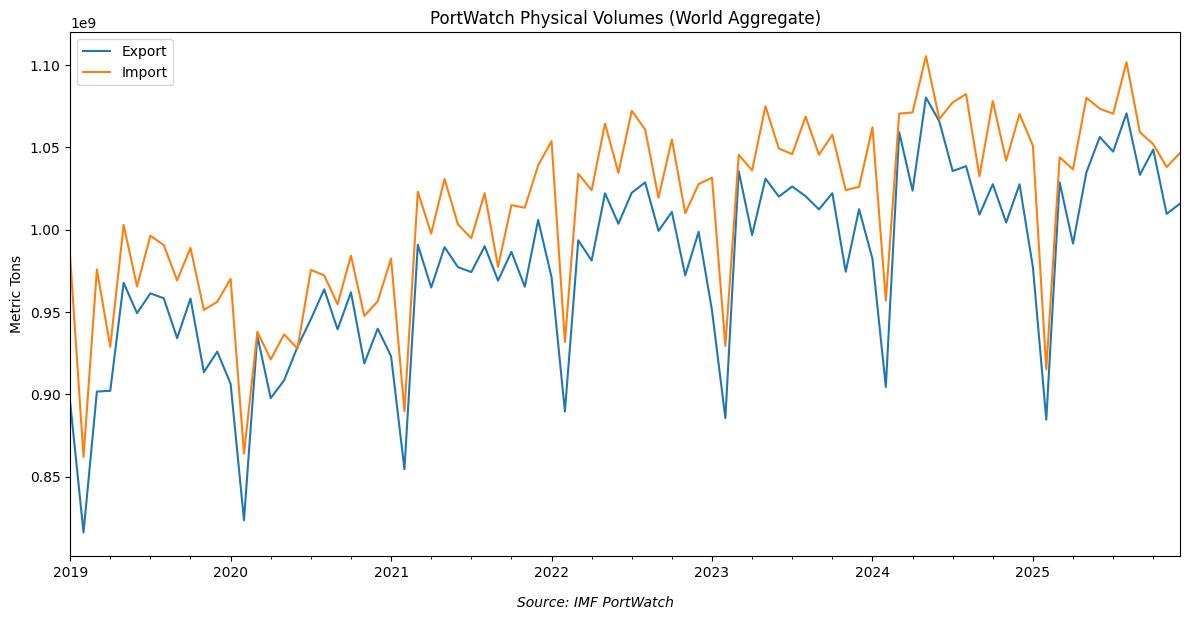

In [ ]:
# Create a figure for better layout control
plt.figure(figsize=(12, 6))

# --- Export series ---
export_series = (
    portwatch[('cargo', 'export')] +
    portwatch[('dry_bulk', 'export')] +
    portwatch[('tanker', 'export')]
)
export_series.plot(label='Export')

# --- Import series ---
import_series = (
    portwatch[('cargo', 'import')] +
    portwatch[('dry_bulk', 'import')] +
    portwatch[('tanker', 'import')]
)
import_series.plot(label='Import')

# Plot formatting
plt.legend()
plt.title("PortWatch Physical Volumes (World Aggregate)")
plt.ylabel("Metric Tons")
plt.xlabel("")

# Add footnote below the plot
plt.figtext(0.5, -0.02, "Source: IMF PortWatch", ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()


## Baci $/MT unit values

<h3 style="font-family: Arial, sans-serif; margin-bottom: 10px;">
  Sample BACI data showing Brazilian exports of Soy beans
</h3>
<p style="font-size: 8px; font-style: italic; color: #555; margin-top: 8px;">The CEPII BACI is a unique database that provides harmonized trade data at the country and product level (6-digit HS codes) in both value (US$) and volume terms (metric tons).</p>
<p style="font-size: 8px; font-style: italic; color: #555; margin-top: 8px;">
  Source: Retrieved from  :
  <a href="https://www.cepii.fr/CEPII/en/bdd_modele/bdd_modele_item.asp?id=37" target="_blank">
    CEPII BACI
  </a>
</p>

<table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 14px;">
  <thead style="background-color: #1f4e79; color: white;">
    <tr>
      <th style="border: 1px solid #ddd; padding: 8px;">Year</th>
      <th style="border: 1px solid #ddd; padding: 8px;">Exporter</th>
      <th style="border: 1px solid #ddd; padding: 8px;">Importer</th>
      <th style="border: 1px solid #ddd; padding: 8px;">Product Code</th>
      <th style="border: 1px solid #ddd; padding: 8px;">Product Label</th>
      <th style="border: 1px solid #ddd; padding: 8px;">Value (US$)</th>
      <th style="border: 1px solid #ddd; padding: 8px;">Quantity (Metric Tons)</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f9f9f9;">
      <td style="border: 1px solid #ddd; padding: 8px;">2023</td>
      <td style="border: 1px solid #ddd; padding: 8px;">BRAZIL</td>
      <td style="border: 1px solid #ddd; padding: 8px;">Pakistan</td>
      <td style="border: 1px solid #ddd; padding: 8px;">120110</td>
      <td style="border: 1px solid #ddd; padding: 8px;">Soya beans: seed, whether or not broken</td>
      <td style="border: 1px solid #ddd; padding: 8px;">$22,223.95</td>
      <td style="border: 1px solid #ddd; padding: 8px;">37,674.64</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ddd; padding: 8px;">2023</td>
      <td style="border: 1px solid #ddd; padding: 8px;">BRAZIL</td>
      <td style="border: 1px solid #ddd; padding: 8px;">Malaysia</td>
      <td style="border: 1px solid #ddd; padding: 8px;">120110</td>
      <td style="border: 1px solid #ddd; padding: 8px;">Soya beans: seed, whether or not broken</td>
      <td style="border: 1px solid #ddd; padding: 8px;">$9,769.08</td>
      <td style="border: 1px solid #ddd; padding: 8px;">16,076.20</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="border: 1px solid #ddd; padding: 8px;">2023</td>
      <td style="border: 1px solid #ddd; padding: 8px;">BRAZIL</td>
      <td style="border: 1px solid #ddd; padding: 8px;">Paraguay</td>
      <td style="border: 1px solid #ddd; padding: 8px;">120110</td>
      <td style="border: 1px solid #ddd; padding: 8px;">Soya beans: seed, whether or not broken</td>
      <td style="border: 1px solid #ddd; padding: 8px;">$4,174.72</td>
      <td style="border: 1px solid #ddd; padding: 8px;">3,407.92</td>
    </tr>
  </tbody>
</table>



**How can we construct the unit values?**  

Complementing this data with a mapping between vessel types and HS codes, provided by Cerdeiro, Komaromi, Liu, and Saeed (2020), we can calculate the average unit value of goods exported/imported by vessel type for the base period (2019).   

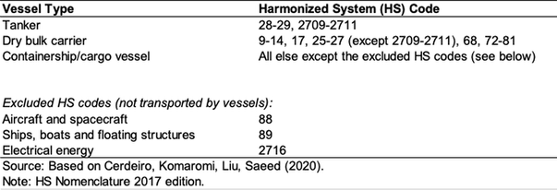

#### Load data

In [ ]:
# Load the pre-computed BACI unit values for the World, different country aggregates and individual countries

baci_filepath = os.path.join(data_path, 'baci_usd_per_ton.csv')

baci_usd_per_ton = fetch_baci_local(baci_filepath,
                                    iso3=country_id)

baci_usd_per_ton

index   cargo         dry_bulk        tanker       
       export  import   export import export import
WLD    4350.0  4350.0    288.0  288.0  539.0  539.0

#### Plot

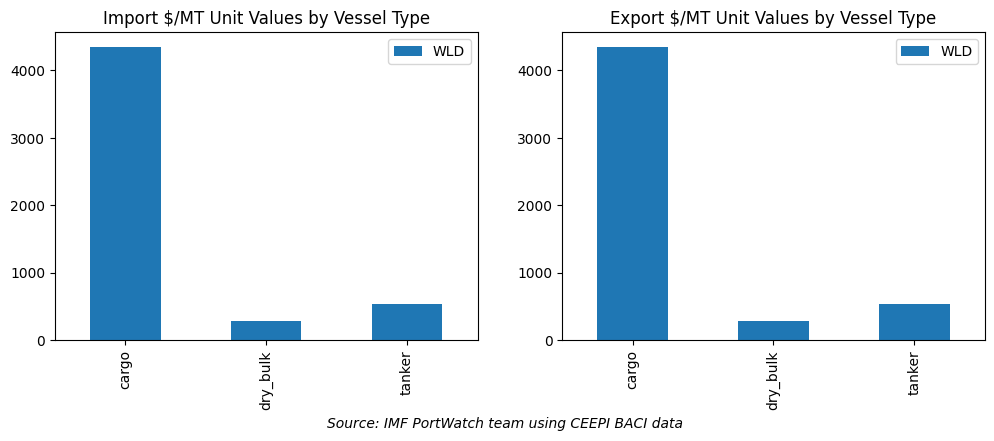

In [ ]:
# Create two subplots: one for import, one for export
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# --- Plot Import Price Indexes ---
baci_usd_per_ton.loc['WLD'].xs('import', axis=0, level=1).plot.bar(
    legend=True,
    ax=axs[0],
    title=f"Import $/MT Unit Values by Vessel Type",
    xlabel=''
)

# --- Plot Export Price Indexes ---
baci_usd_per_ton.loc['WLD'].xs('export', axis=0, level=1).plot.bar(
    legend=True,
    ax=axs[1],
    title=f"Export $/MT Unit Values by Vessel Type",
    xlabel=''
)


# Add a footnote below the entire figure
fig.text(0.5, -0.1, 'Source: IMF PortWatch team using CEEPI BACI data',
         ha='center', va='center', fontsize=10, style='italic');


## Prices

#### Global Price Indexes by Ship Type

> Generate your API Key from the World Trade Organization [WTO API PORTAL](https://apiportal.wto.org/)


In [ ]:
#It is a good practice to store your API Key in CoLab's "SECRET"
#It is similar to an environmental variable.
#(see the key symbol on the left menu)
#The code below imports the API key named 'WTO_API_KEY' without revealing the actual key.

from google.colab import userdata
wto_api_key = userdata.get('WTO_API_KEY')

**Brief function description**

>🔍`compile_price_indexes`

> This function compiles a harmonized table of price indexes for three major maritime vessel types:

> - Tanker: IMF fuel prices (excluding coal)

> - Dry Bulk: IMF non-fuel commodities + coal (excluding precious metals)

> - Cargo: WTO unit value indexes (imports and exports), extended using US CPI index and Cleveland FED US CPI nowcast.

In [ ]:
# compile_price_indexes function compiles all price indexes dircetly from APIs
# and always return the latest values
price_indexes = compile_price_indexes(wto_api_key=wto_api_key, end_date=LAST_MONTH)

# DATA BACKUP
#price_indexes = pd.read_csv(os.path.join(data_path, 'price_indexes.csv'),
#                            header=[0, 1],
#                            index_col=0)
#price_indexes.index = pd.to_datetime(price_indexes.index)


# Check the columns of the DataFrame
price_indexes.tail()

cargo                dry_bulk                  tanker  \
                export      import      export      import      export   
date                                                                     
2025-08-01  114.140547  112.834361  143.965247  143.965247  158.575482   
2025-09-01  114.573393  113.262254  146.771669  146.771669  158.868683   
2025-10-01  114.099648  112.793930  145.845749  145.845749  151.762803   
2025-11-01  113.625903  112.325606  145.760792  145.760792  153.053521   
2025-12-01  113.178742  111.883562  148.364945  148.364945  147.061446   

                        
                import  
date                    
2025-08-01  158.575482  
2025-09-01  158.868683  
2025-10-01  151.762803  
2025-11-01  153.053521  
2025-12-01  147.061446

#### From Price Indexes to Prices


To calculate the change in the average unit value of goods exported/imported by vessel type monthly, we simply multiply the BACI unit values for each group times the price indexes.

Note: Unit values are region/country specific, while price indexes are global.

In [ ]:
prices = to_prices(baci_rel_prices=baci_usd_per_ton, price_indexes=price_indexes)

print(prices.shape)

prices.tail()

(84, 6)


cargo                 dry_bulk                  tanker  \
                 export       import      export      import      export   
date                                                                       
2025-08-01  4750.168647  4734.308845  384.645420  384.645420  654.967072   
2025-09-01  4768.182342  4752.262395  392.143601  392.143601  656.178084   
2025-10-01  4748.466566  4732.612447  389.669734  389.669734  626.828544   
2025-11-01  4728.750790  4712.962498  389.442745  389.442745  632.159619   
2025-12-01  4710.141368  4694.415208  396.400505  396.400505  607.410450   

                        
                import  
date                    
2025-08-01  654.967072  
2025-09-01  656.178084  
2025-10-01  626.828544  
2025-11-01  632.159619  
2025-12-01  607.410450

#### Plot

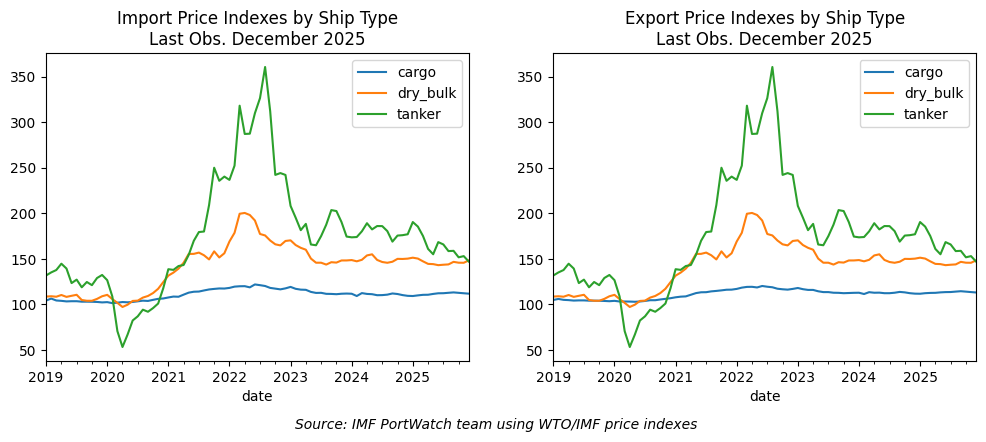

In [ ]:
# Get the latest date available in the index
price_indexes.index = pd.to_datetime(price_indexes.index)

latest_date = price_indexes.index.max().strftime('%B %Y')

# Create two subplots: one for import, one for export
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# --- Plot Import Price Indexes ---
price_indexes.xs('import', axis=1, level=1).plot(
    legend=True,
    ax=axs[0],
    title=f"Import Price Indexes by Ship Type\nLast Obs. {latest_date}"
)

# --- Plot Export Price Indexes ---
price_indexes.xs('export', axis=1, level=1).plot(
    legend=True,
    ax=axs[1],
    title=f"Export Price Indexes by Ship Type\nLast Obs. {latest_date}"
)

# Add a footnote below the entire figure
fig.text(0.5, -0.05, 'Source: IMF PortWatch team using WTO/IMF price indexes',
         ha='center', va='center', fontsize=10, style='italic');


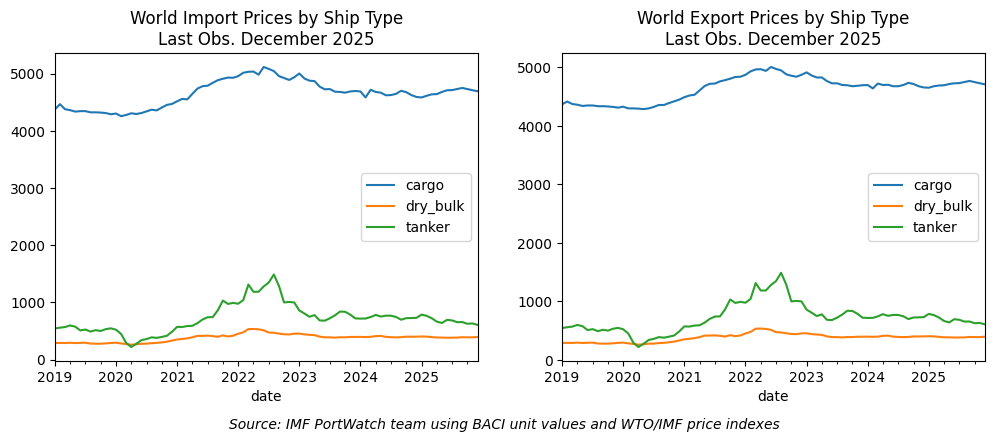

In [ ]:
# Get the latest date available in the index
prices.index = pd.to_datetime(prices.index)

latest_date = prices.index.max().strftime('%B %Y')

# Create two subplots: one for import, one for export
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# --- Plot Import Price Indexes ---
prices.xs('import', axis=1, level=1).plot(
    legend=True,
    ax=axs[0],
    title=f"World Import Prices by Ship Type\nLast Obs. {latest_date}"
)

# --- Plot Export Price Indexes ---
prices.xs('export', axis=1, level=1).plot(
    legend=True,
    ax=axs[1],
    title=f"World Export Prices by Ship Type\nLast Obs. {latest_date}"
)

# Add a footnote below the entire figure
fig.text(0.5, -0.05, 'Source: IMF PortWatch team using BACI unit values and WTO/IMF price indexes',
         ha='center', va='center', fontsize=10, style='italic');


## Compute PWI Trade Value

<h4> 📘 Estimating Trade Value Indexes</h4>

 <details>
  <summary> This process transforms physical volumes (in metric tons) data from <b>PortWatch</b> into estimated <b>trade values</b> by combining it with BACI unit values and percentage changes in the average unit values. </summary>

From: *Arslanalp S., S. M. Choi, P. Kamali, R. Koepke, M. McKetty, M. Ruta, M. Saraiva, A. Sozzi, and J. Verschuur (2025), "Nowcasting Global Trade from Space," IMF Working Paper 25/93.*

* First, construct an average unit values of goods (US$/metric ton) transported by the different vessel types:
 - 🚢 Tanker,
 - 🚢 Dry Bulk, and
 - 🚢Containerships and other cargo vessels

* This allows us to calculate the global trade value, as shown below in Equations 1 and 2.

 </details>

 <details>
<summary> Formula </summary>

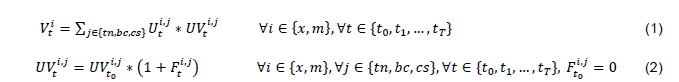


where:
-  <b> 𝑉𝑡𝑥 </b> and <b> 𝑉𝑡𝑚</b> are global exports and imports in value terms respectively at period t,
- <b>𝑈𝑡𝑥,𝑗 </b>and <b>𝑈𝑡𝑚,𝑗 </b>are global export and import shipments in physical volume respectively by vessel type j at period t, respectively [previously obtained],
- <b>𝑈𝑉𝑡𝑥,𝑗 </b>and <b>𝑈𝑉𝑡𝑚,𝑗 </b>are average unit values of goods exported and imported, respectively, by vessel type j at period t, and
- <b>𝐹𝑡𝑥,𝑗 </b> and <b>𝐹𝑡𝑚,𝑗 </b>are percentage changes in the average unit value of goods exported and imported, respectively, by vessel type j between the base period (to) and period t.

- In terms of vessel types (j), <b>tn, db, and cs</b> stand for <b>tanker, dry bulk carrier,</b> and <b>containership/other cargo vessel</b>, respectively.



#### Import/Export Values

In [ ]:
# Compute trade value series from combination of PortWatch import/export physical volumes
# with prices by vessel types. Add the total trade values as well.
values = to_value_series(
    portwatch=portwatch,
    prices=prices
)

values.tail().div(10**9)

cargo                 dry_bulk                  tanker  \
                 export       import      export      import      export   
date                                                                       
2025-08-01  1690.901946  1663.240713  162.301481  166.649626  191.725874   
2025-09-01  1621.172995  1608.119272  161.096169  165.534496  185.389515   
2025-10-01  1630.231319  1603.829963  161.400996  161.778102  182.491317   
2025-11-01  1620.599634  1574.577865  156.426274  160.122482  167.675990   
2025-12-01  1625.470726  1588.987011  161.307533  161.420049  160.231114   

                              total               
                import       import       export  
date                                              
2025-08-01  207.698723  2037.589062  2044.929301  
2025-09-01  195.972606  1969.626373  1967.658680  
2025-10-01  186.722989  1952.331053  1974.123631  
2025-11-01  185.091648  1919.791995  1944.701899  
2025-12-01  182.733920  1933.140980  1947.009373

#### Convert to Indexes

In [ ]:
value_indexes = to_index(df=values,
                         base_year=2019) # The to_index function normalizes the value time series by setting a base period

# Show the last few rows of the resulting DataFrame
value_indexes.tail()


cargo                dry_bulk                  tanker  \
                export      import      export      import      export   
date                                                                     
2025-08-01  129.975895  129.503088  149.778722  148.197117  143.579306   
2025-09-01  124.615985  125.211228  148.666409  147.205461  138.834146   
2025-10-01  125.312278  124.877254  148.947716  143.864998  136.663749   
2025-11-01  124.571912  122.599630  144.356831  142.392699  125.568876   
2025-12-01  124.946342  123.721553  148.861465  143.546591  119.993570   

                             total              
                import      import      export  
date                                            
2025-08-01  138.522202  131.736521  132.544136  
2025-09-01  130.701607  127.342520  127.535763  
2025-10-01  124.532685  126.224323  127.954796  
2025-11-01  123.444681  124.120571  126.047797  
2025-12-01  121.872223  124.983625  126.197358

#### Plots

<h4> 🎯 PortWatch-derived import/export <b>value indexes</b> </h4>

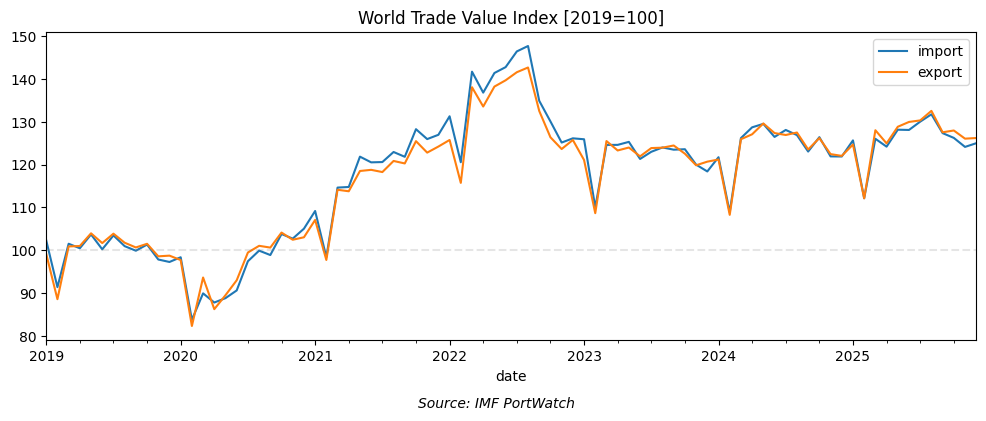

In [ ]:
# Create plot
fig, ax = plt.subplots(figsize=(12, 4))

# --- Plot Value Import/Export Indexes ---
value_indexes[('total', 'import')].plot(
    label="import",
    ax=ax,
    legend=True)
value_indexes[('total', 'export')].plot(
    label="export",
    ax=ax,
    legend=True)

plt.title('World Trade Value Index [2019=100]')

# Add 0 line
plt.hlines(y=100,
           xmin=value_indexes.index.min(),
           xmax=value_indexes.index.max(),
           alpha=0.2, colors='grey', linestyles='--')

# Add a footnote below the entire figure
fig.text(0.5, -0.05, 'Source: IMF PortWatch',
         ha='center', va='center', fontsize=10, style='italic');

## Compute PWI Trade Volume

<h4> 📘 Estimating Trade Volume Indexes </h4>

 <details>
  <summary> This process transforms import/export trade values (in $) derived in previous step into estimated <b>trade volume  (in constant prices)</b> using import/export price deflators. </summary>

From: *Arslanalp S., S. M. Choi, P. Kamali, R. Koepke, M. McKetty, M. Ruta, M. Saraiva, A. Sozzi, and J. Verschuur (2025), "Nowcasting Global Trade from Space," IMF Working Paper 25/93.*

* First, to compute export/import price deflators, we construct a Laspeyres-type index   

* This allows us to calculate the global trade volume, as shown below in Equations 3.

 </details>

 <details>
<summary> Formula </summary>

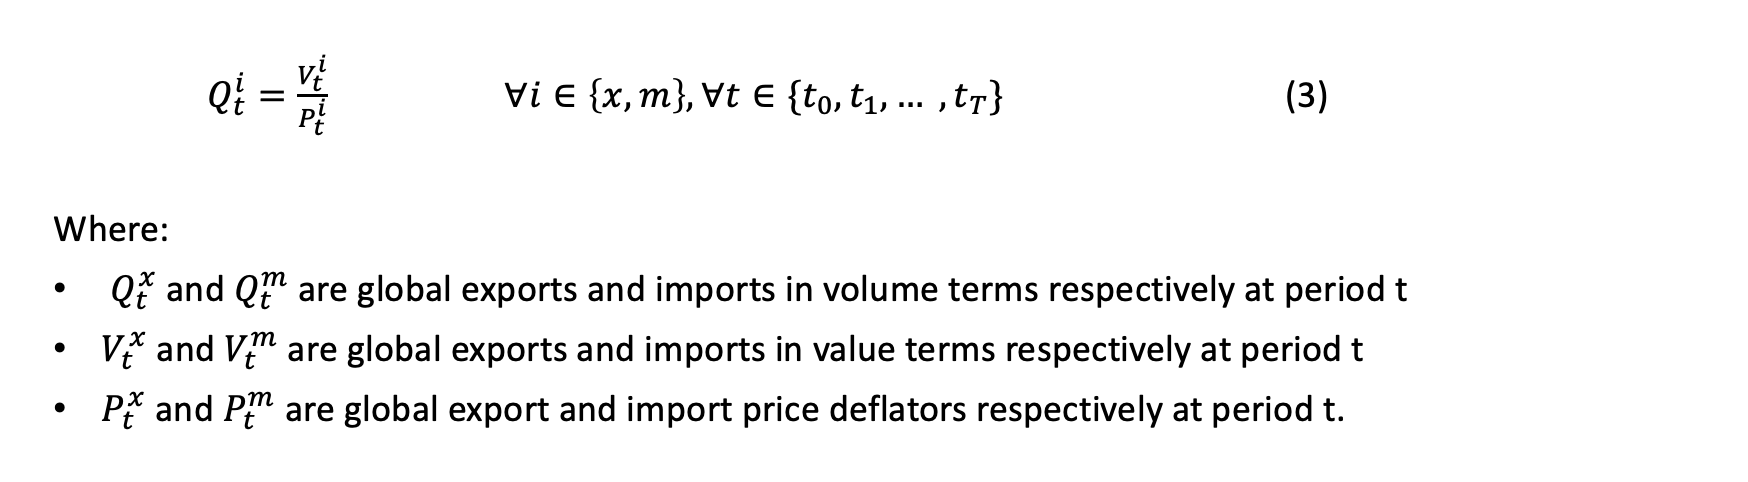

For export/import price deflators, we use a Laspeyres-type index. This is to mimic the approach used by many national statistical agencies, including those in the euro area and the United States. The Laspeyres-type index applies the base period quantities for both the base period and the period for which the index is computed to estimate the price effect, as shown in Equation 4.

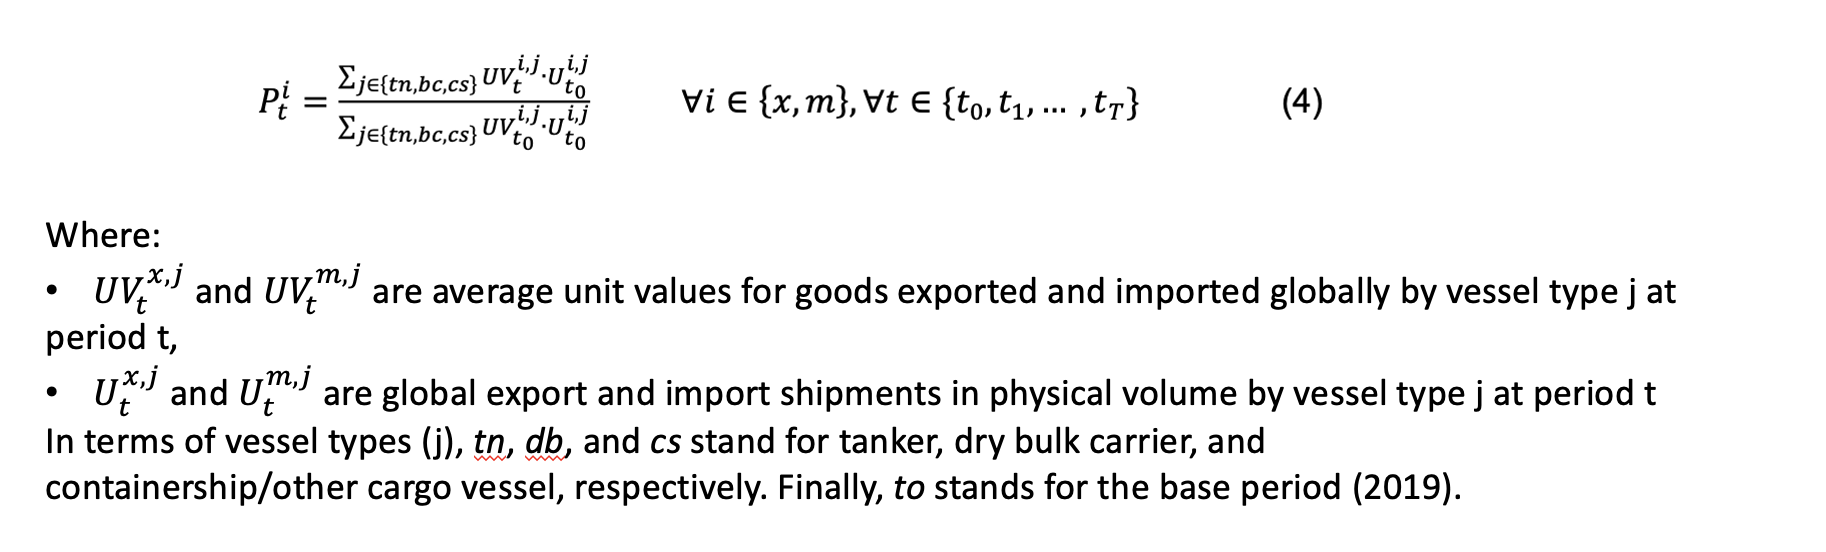

 </details>

#### Import/Export Price Deflators

In [ ]:
# Calculate import/export price indexes deflators using Laspeyres-type index
chpis = to_laspeyres_price_index(portwatch=portwatch, prices=prices)

print(chpis.shape)

chpis.tail()

(84, 2)


,export,import
date,,
2025-08-01,111.977376,111.861817
2025-09-01,112.528811,112.415574
2025-10-01,111.614361,111.449957
2025-11-01,111.312442,111.165078
2025-12-01,110.723391,110.541364


<Axes: xlabel='date'>

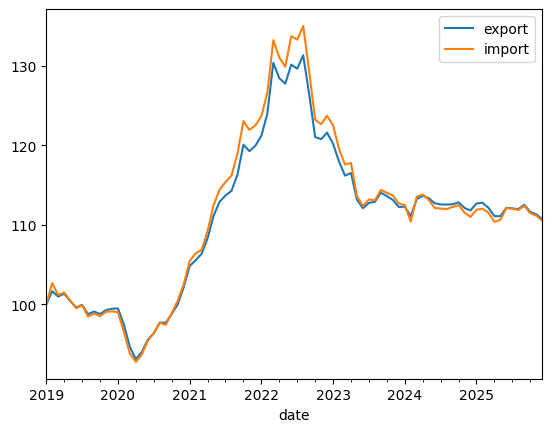

In [ ]:
chpis.plot()

#### Import/Export Volumes

In [ ]:
volume = to_volume_weighted_series(chained_price_index=chpis, values=values)
volume.tail()

,export,import
date,,
2025-08-01,1.826199e+10,1.821523e+10
2025-09-01,1.748582e+10,1.752094e+10
2025-10-01,1.768700e+10,1.751756e+10
2025-11-01,1.747066e+10,1.726974e+10
2025-12-01,1.758444e+10,1.748794e+10


#### Convert to Indexes

In [ ]:
volume_indexes = to_index(df=volume, base_year=2019)
volume_indexes.tail()

,export,import
date,,
2025-08-01,118.286062,117.666611
2025-09-01,113.258706,113.181614
2025-10-01,114.561800,113.159774
2025-11-01,113.160508,111.558924
2025-12-01,113.897509,112.968464


#### Plot

<h4> 🎯 PortWatch-derived import/export <b>volume indexes</b> </h4>

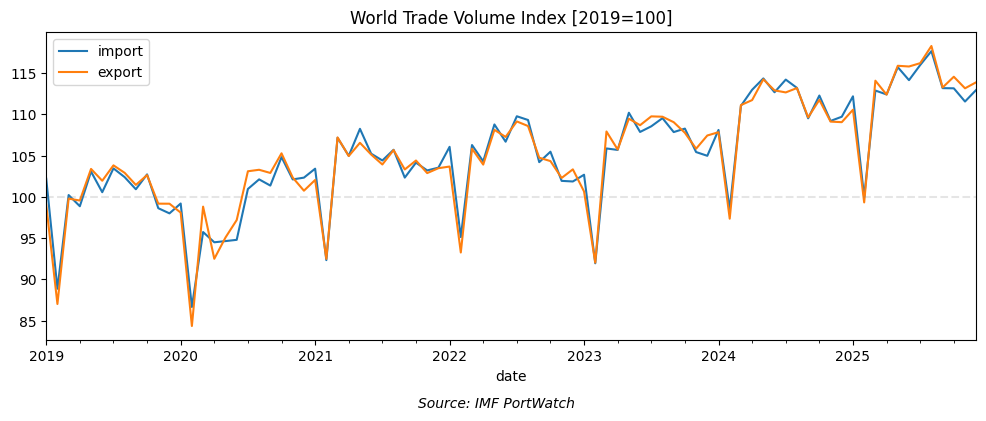

In [ ]:
# Create plot
fig, ax = plt.subplots(figsize=(12, 4))

# --- Plot Volume Import/Export Indexes ---
volume_indexes['import'].plot(
    label="import",
    ax=ax,
    legend=True)
volume_indexes['export'].plot(
    label="export",
    ax=ax,
    legend=True)

plt.title('World Trade Volume Index [2019=100]')

# Add 0 line
plt.hlines(y=100,
           xmin=volume_indexes.index.min(),
           xmax=volume_indexes.index.max(),
           alpha=0.2, colors='grey', linestyles='--')

# Add a footnote below the entire figure
fig.text(0.5, -0.05, 'Source: IMF PortWatch',
         ha='center', va='center', fontsize=10, style='italic');

## Combine Import/Export Value and Volume Indexes into a single dataset

In [ ]:
trade_df = (
    pd.concat([value_indexes['total'].rename(columns={c:'value_'+c for c in value_indexes['total'].columns}),
               volume_indexes.rename(columns={c:'volume_'+c for c in volume_indexes.columns})], axis=1)
)

trade_df

,value_import,value_export,volume_export,volume_import
date,,,,
2019-01-01,102.294281,99.108266,99.040590,102.206915
2019-02-01,91.350454,88.537276,87.029522,88.877185
2019-03-01,101.492255,100.861726,99.797097,100.228846
2019-04-01,100.437956,100.967205,99.564989,98.873021
2019-05-01,103.663191,103.929572,103.392252,103.075410
...,...,...,...,...
2025-08-01,131.736521,132.544136,118.286062,117.666611
2025-09-01,127.342520,127.535763,113.258706,113.181614
2025-10-01,126.224323,127.954796,114.561800,113.159774


In [ ]:
trade_df.to_csv(os.path.join(output_path, 'pw_trade_nowcast.csv'))

## Comparison with Official data from CPB World Trade Monitor

Source: https://www.cpb.nl/en/worldtrademonitor

In [ ]:
# Get the most recent data from CPB

# PW functions
cpb_value, cpb_volume = fetch_and_tweak(fetch_cpb, tweak_cpb)

print("CPB Estimates for regions: ", cpb_value.index.levels[0].to_list())

# BACKUP files
#cpb_value = (
#    pd.read_csv(os.path.join(data_path, 'cpb_value.csv'))
#    .assign(date=lambda x: pd.to_datetime(x['date']))
#    .set_index(['country', 'date']))

#cpb_volume = (
#    pd.read_csv(os.path.join(data_path, 'cpb_volume.csv'))
#    .assign(date=lambda x: pd.to_datetime(x['date']))
#    .set_index(['country', 'date']))

# Filter for World
cpb_value = cpb_value.loc['World']
cpb_volume = cpb_volume.loc['World']

cpb_value.tail()

CPB Estimates for regions:  ['Advanced Asia excl Japan', 'Advanced Economies', 'Africa and Middle East', 'China', 'Eastern Europe / CIS', 'Emerging Asia excl China', 'Emerging Economies', 'Euro Area', 'Japan', 'Latin America', 'Other Advanced Economies', 'United Kingdom', 'United States', 'World']


flow,import,export
date,,
2025-07-01,137.438915,137.969252
2025-08-01,135.679569,136.269064
2025-09-01,138.017557,139.196122
2025-10-01,135.882222,137.807184
2025-11-01,137.645176,140.497728


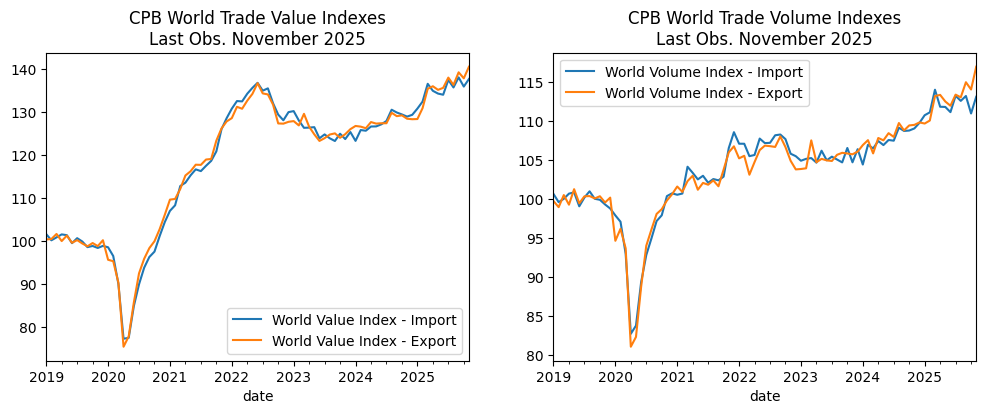

In [ ]:
# Get the most recent date from the CPB
latest_date = pd.to_datetime(cpb_value.index.max()).strftime('%B %Y')

# Create side-by-side subplots for value and volume indexes
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# --- Plot 1: Trade Value Indexes ---
# Plot Import Value Index
cpb_value['import'].plot(
    label='World Value Index - Import', legend=True, ax=axs[0]
)

# Plot Export Value Index with title
cpb_value['export'].plot(
    label='World Value Index - Export',
    legend=True,
    ax=axs[0],
    title=f"CPB World Trade Value Indexes\nLast Obs. {latest_date}"
)

# --- Plot 2: Trade Volume Indexes ---
# Plot Import Volume Index
cpb_volume['import'].plot(
    label='World Volume Index - Import', legend=True, ax=axs[1]
)

# Plot Export Volume Index with title
cpb_volume['export'].plot(
    label='World Volume Index - Export',
    legend=True,
    ax=axs[1],
    title=f"CPB World Trade Volume Indexes\nLast Obs. {latest_date}"
);

<h3> 🎯 Compare PortWatch-derived trade value and volume indexes  with CPB indexes </h3>



In [ ]:
pw_indexes_3ma = moving_avg(df=trade_df, period=3)
trade_df.head()

,value_import,value_export,volume_export,volume_import
date,,,,
2019-01-01,102.294281,99.108266,99.040590,102.206915
2019-02-01,91.350454,88.537276,87.029522,88.877185
2019-03-01,101.492255,100.861726,99.797097,100.228846
2019-04-01,100.437956,100.967205,99.564989,98.873021
2019-05-01,103.663191,103.929572,103.392252,103.075410


In [ ]:
# Prepare series and compute correlations - Import Values
imp_val_cbp = cpb_value['import']
imp_val_pw = trade_df['value_import']
imp_correlation = correlate(imp_val_cbp, imp_val_pw)
imp_correlation

np.float64(0.91)

In [ ]:
# Prepare series and compute correlations - Export Values
exp_val_cbp = cpb_value['export']
exp_val_pw = trade_df['value_export']
exp_correlation = correlate(exp_val_cbp, exp_val_pw)
exp_correlation

np.float64(0.92)

In [ ]:
# Prepare series and compute correlations - Import Volumes
imp_vol_cbp = cpb_volume['import']
imp_vol_pw = trade_df['volume_import']
imp_vol_correlation = correlate(imp_vol_cbp, imp_vol_pw)
imp_vol_correlation


np.float64(0.72)

In [ ]:
# Prepare series and compute correlations - Export Volumes
exp_vol_cbp = cpb_volume['export']
exp_vol_pw = trade_df['volume_export']
exp_vol_correlation = correlate(exp_vol_cbp, exp_vol_pw)
exp_vol_correlation

np.float64(0.72)

In [ ]:
def plot_series(ax, s1, s2, label1, label2, title):
    """Plot two time series on the same axis."""
    s1.plot(ax=ax, label=label1, legend=True)
    s2.plot(ax=ax, label=label2, legend=True)
    ax.set_title(title)

<h4> 🎯 Compare PortWatch-derived <b>value index</b>  vs. CPB <b>value index</b> </h4>

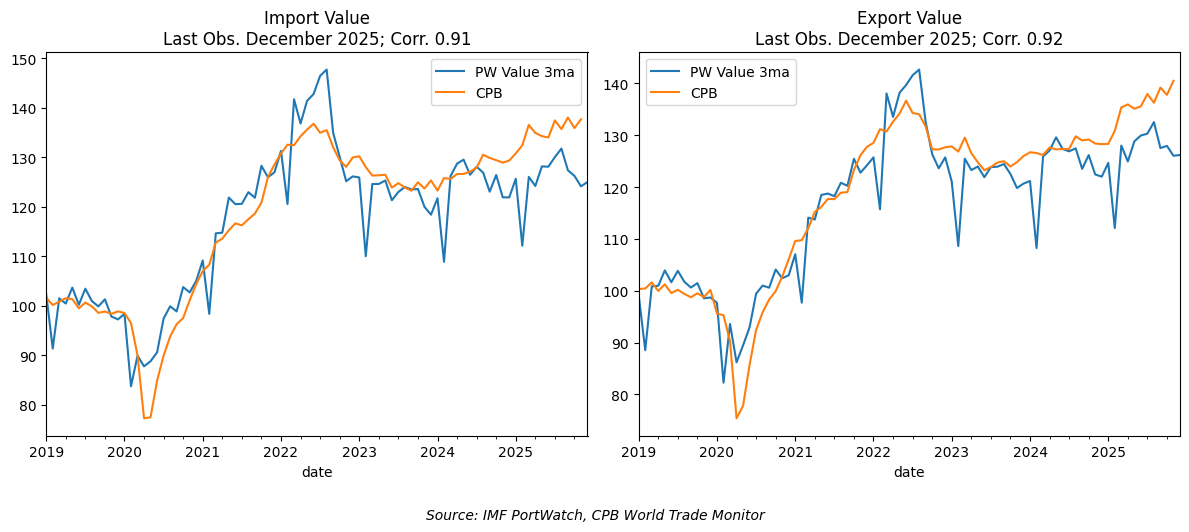

In [ ]:
# Format latest date
latest_date = trade_df.index.max().strftime('%B %Y')

# Create Values plots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

plot_series(
    axs[0], imp_val_pw, imp_val_cbp,
    label1='PW Value 3ma', label2='CPB',
    title=f"Import Value\nLast Obs. {latest_date}; Corr. {imp_correlation:.2f}"
)

plot_series(
    axs[1], exp_val_pw, exp_val_cbp,
    label1='PW Value 3ma', label2='CPB',
    title=f"Export Value\nLast Obs. {latest_date}; Corr. {exp_correlation:.2f}"
)

# Source note and layout
fig.text(0.5, -0.05, "Source: IMF PortWatch, CPB World Trade Monitor", ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()


<h4> 🎯 Compare PortWatch-derived <b>volume index</b>  vs. CPB <b>volume index</b> </h4>



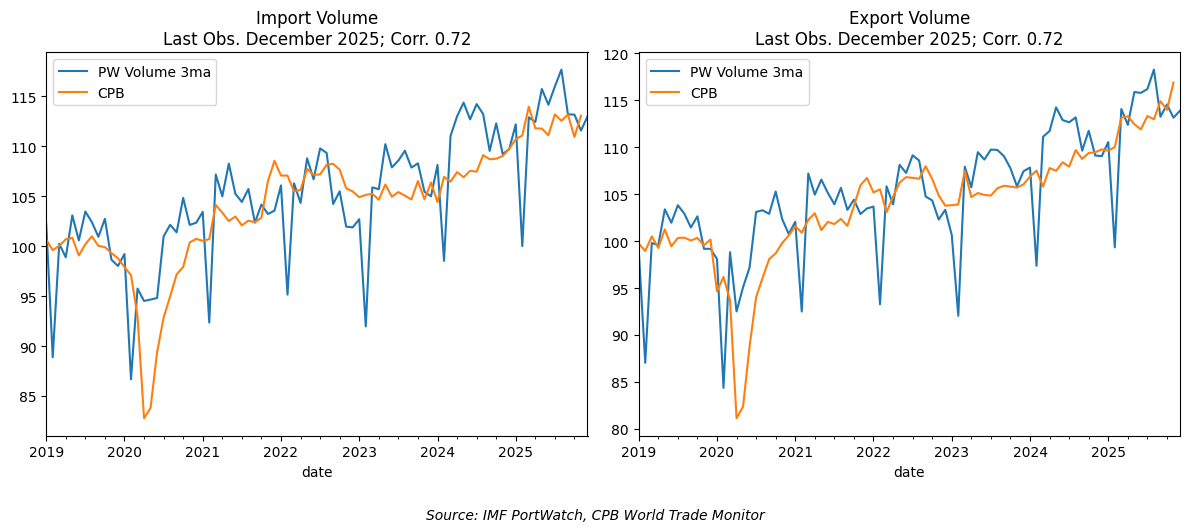

In [ ]:
# Format latest date
latest_date = trade_df.index.max().strftime('%B %Y')

# --- Create Volume plots ---
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

plot_series(
    axs[0], imp_vol_pw, imp_vol_cbp,
    label1='PW Volume 3ma', label2='CPB',
    title=f"Import Volume\nLast Obs. {latest_date}; Corr. {imp_vol_correlation:.2f}"
)

plot_series(
    axs[1], exp_vol_pw, exp_vol_cbp,
    label1='PW Volume 3ma', label2='CPB',
    title=f"Export Volume\nLast Obs. {latest_date}; Corr. {exp_vol_correlation:.2f}"
)

# Source note and layout
fig.text(0.5, -0.05, "Source: IMF PortWatch, CPB World Trade Monitor", ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()



## Annex

### Data Sources

The notebook requires input data from several sources:
| Input Source                          | Link                                                                 |
|---------------------------------|----------------------------------------------------------------------|
| IMF PortWatch                   | [portwatch.imf.org](https://portwatch.imf.org/pages/data-and-methodology) |
| IMF Primary Commodity Prices    | [IMF PCP](https://www.imf.org/en/Research/commodity-prices-)        |
| CEPII - Base pour l'Analyse du Commerce International                           | [CEPII-BACI](https://www.cepii.fr/CEPII/en/bdd_modele/bdd_modele_item.asp?id=37)                                                 |
| US CPI (U.S. Bureau of Labor Statistics API)                | [api.bls.gov](https://api.bls.gov/publicAPI/v1/timeseries/data/)        |
| Federal Reserve Bank of Cleveland CPI                   | [clevelandfed.org](https://www.clevelandfed.org/indicators-and-data/inflation-nowcasting) |
| WTO -  Import and Export price indices of manufactured goods       | [api.wto.org](https://api.wto.org/timeseries/v1/data?)              |
| CPB World Trade Monitor         | [cpb.nl](https://www.cpb.nl/en/worldtrademonitor)                   |


### Country Composition of WEO Groups
Source: [IMF World Economic Outlook Database (April 2023)](https://www.imf.org/en/Publications/WEO/weo-database/2023/April/groups-and-aggregates)


| Source | Code | Name                                                | # Countries |
|:-------:|:----:|:---------------------------------------------------|-------------:|
| WEO | WLD | World | All |
| WEO | 110 | Advanced Economies | 41 |
| WEO | 163 | Euro Area | 20 |
| WEO | 119 | Major Advanced Economies (G7) | 7 |
| WEO | 123 | Other Advanced Economies (Advanced Economies excluding G7 and Euro Area) | 17 |
| WEO | 998 | European Union | 27 |
| WEO | 510 | ASEAN-5 | 5 |
| WEO | 200 | Emerging Market and Developing Economies | 0 |
| WEO | 505 | Emerging and Developing Asia | 0 |
| WEO | 903 | Emerging and Developing Europe | 0 |
| WEO | 205 | Latin America and the Caribbean | 0 |
| WEO | 400 | Middle East and Central Asia | 0 |
| WEO | 603 | Sub-Saharan Africa | 0 |
| APD | 511 | Asian Advanced Economies excluding Japan | 7 |
| APD | 512 | Asian Emerging Markets excluding China | 25 |
| APD | 513 | ASEAN-10 | 9 |
